In [1]:
%run ../scripts/notebook_settings.py
import sgkit as sg
import xarray as xr
import glob

In [2]:
table_desc = "~/primatediversity/data/gVCFs_recalling_10_12_2024_metadata/plots/SupTable_Sample_Stats_wGT_QC_MQ.tsv"
metadata_path = "~/primatediversity/data/gVCFs_recalling_10_12_2024_metadata/"

metadata_table = pd.read_csv(table_desc, sep="\t")

metadata_20x_filt = metadata_table.loc[(metadata_table.finalQC != "fail")
                              & (metadata_table.cov_chrA >= 20)
                              & (metadata_table.remove_as_relative != True)
                              & (metadata_table.remove_manual != True)
                              & (~metadata_table.ID.str.startswith("SAMEA11633"))
                             ]

count_sub = metadata_20x_filt.loc[~metadata_20x_filt.cov_chrX.isna()][["gSEX", "group", "species_genotyping", "species"]].value_counts().reset_index()
used_species = count_sub.loc[(count_sub.gSEX == "F") | ((count_sub.gSEX == "M") & (count_sub["count"] >= 2))].species_genotyping.unique()
metadata_20x_filt = metadata_20x_filt.loc[metadata_20x_filt.species_genotyping.isin(used_species)]

In [3]:
# Loading in the species
df_l = []
for long_form in used_species:
    df_path = "../results/lifted_window_stats_20x_inds/{}_10kb_pi_windowed_annotated.txt".format(long_form)
    s_df = pd.read_csv(df_path, sep="\t")
    s_df["species"] = long_form
    df_l.append(s_df)
all_pi_df = pd.concat(df_l)

In [4]:
chr_names = ['NC_060925.1', 'NC_060926.1', 'NC_060927.1', 'NC_060928.1',
       'NC_060929.1', 'NC_060930.1', 'NC_060931.1', 'NC_060932.1',
       'NC_060933.1', 'NC_060934.1', 'NC_060935.1', 'NC_060936.1',
       'NC_060937.1', 'NC_060938.1', 'NC_060939.1', 'NC_060940.1',
       'NC_060941.1', 'NC_060942.1', 'NC_060943.1', 'NC_060944.1',
       'NC_060945.1', 'NC_060946.1', 'NC_060947.1']
chr_tag = ["chrX" if i == 22 else "aut" for i in range(len(chr_names))]
all_pi_df["chr_type"] = all_pi_df.chrom.map(dict(zip(chr_names, chr_tag)))
all_pi_df

,chrom,window_100kb,pi_window,mapped_bases,pi_per_mapped_base,genes,max_genes,largest_gene,largest_gene_cov,species,chr_type
0,NC_060925.1,0,220.560738,47016,0.004691,NaN,0,NaN,0.00000,Macaca_fascicularis_ssp,aut
1,NC_060925.1,100000,4.757545,1214,0.003919,['OR4F21'],0,OR4F21,0.00938,Macaca_fascicularis_ssp,aut
2,NC_060925.1,200000,212.822104,58860,0.003616,NaN,0,NaN,0.00000,Macaca_fascicularis_ssp,aut
3,NC_060925.1,300000,269.197770,63277,0.004254,['SAMD11' 'NOC2L' 'PLEKHN1' 'KLHL17'],0,SAMD11,0.17321,Macaca_fascicularis_ssp,aut
4,NC_060925.1,400000,237.559592,81586,0.002912,['AGRN' 'PERM1' 'PLEKHN1' 'HES4' 'ISG15'],0,AGRN,0.34747,Macaca_fascicularis_ssp,aut
...,...,...,...,...,...,...,...,...,...,...,...
28336,NC_060947.1,153800000,0.678400,60158,0.000011,['TMLHE'],0,TMLHE,0.94993,Semnopithecus_schistaceus_ssp,chrX
28337,NC_060947.1,153900000,0.258067,67648,0.000004,['SPRY3'],0,SPRY3,0.00867,Semnopithecus_schistaceus_ssp,chrX
28338,NC_060947.1,154000000,0.819000,48192,0.000017,NaN,0,NaN,0.00000,Semnopithecus_schistaceus_ssp,chrX
28339,NC_060947.1,154100000,1.534267,64030,0.000024,['VAMP7'],0,VAMP7,0.52682,Semnopithecus_schistaceus_ssp,chrX


In [5]:
# Test set
species_used = [used_species[i] for i in range(0, len(used_species), 20)]

In [6]:
x_m = np.ones((len(species_used), len(species_used)))
aut_m = np.ones((len(species_used), len(species_used)))
for i in range(len(species_used)):
    for j in range(i):
        s1 = species_used[i]
        s2 = species_used[j]
        merged_df = pd.merge(all_pi_df.loc[(all_pi_df.species == s1) & (all_pi_df.mapped_bases >= 50000)],
                all_pi_df.loc[(all_pi_df.species == s2) & (all_pi_df.mapped_bases >= 50000)],
                on=["chrom", "window_100kb"])
        merged_df_x = merged_df.loc[merged_df.chr_type_x == "chrX"]
        cor_x = merged_df_x[["pi_per_mapped_base_x", "pi_per_mapped_base_y"]].corr(method="spearman").iloc[0, 1]
        x_m[i, j] = cor_x
        x_m[j, i] = cor_x
        merged_df_aut = merged_df.loc[merged_df.chr_type_x == "aut"]
        cor_aut = merged_df_aut[["pi_per_mapped_base_x", "pi_per_mapped_base_y"]].corr(method="spearman").iloc[0, 1]
        aut_m[i, j] = cor_aut
        aut_m[j, i] = cor_aut

In [7]:
(aut_m-x_m).sum()/(len(species_used)*(len(species_used)-1)/2)

nan

In [8]:
(aut_m.sum()-len(species_used))/(len(species_used)*(len(species_used)-1)/2)

0.6404607481573535

In [9]:
(x_m.sum()-len(species_used))/(len(species_used)*(len(species_used)-1)/2)

nan

In [10]:
aut_m.mean()-x_m.mean()

nan

In [11]:
comp_list = []
for i in range(len(aut_m)):
    for j in range(i):
        comp_list.append(aut_m[i, j]-x_m[i, j])

<Axes: ylabel='Count'>

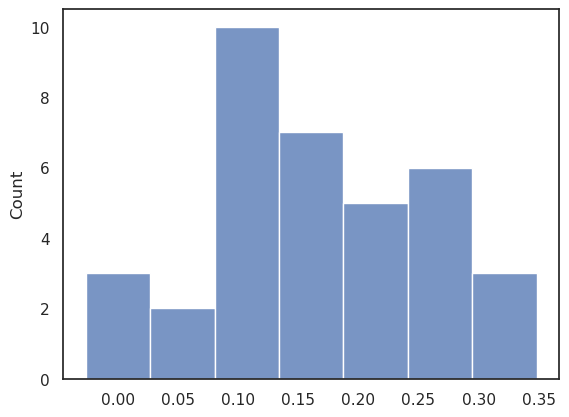

In [12]:
sns.histplot(comp_list)

<Axes: >

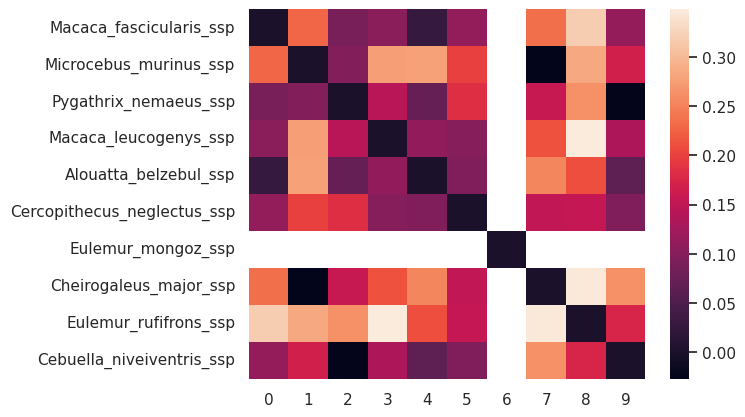

In [13]:
sns.heatmap(aut_m-x_m, yticklabels=species_used)

Full run

In [14]:
species_used = [used_species[i] for i in range(0, len(used_species), 1)]

In [ ]:
x_m = np.ones((len(species_used), len(species_used)))
aut_m = np.ones((len(species_used), len(species_used)))
for i in range(len(species_used)):
    print(i)
    for j in range(i):
        s1 = species_used[i]
        s2 = species_used[j]
        merged_df = pd.merge(all_pi_df.loc[(all_pi_df.species == s1) & (all_pi_df.mapped_bases >= 50000)],
                all_pi_df.loc[(all_pi_df.species == s2) & (all_pi_df.mapped_bases >= 50000)],
                on=["chrom", "window_100kb"])
        merged_df_x = merged_df.loc[merged_df.chr_type_x == "chrX"]
        cor_x = merged_df_x[["pi_per_mapped_base_x", "pi_per_mapped_base_y"]].corr(method="spearman").iloc[0, 1]
        x_m[i, j] = cor_x
        x_m[j, i] = cor_x
        merged_df_aut = merged_df.loc[merged_df.chr_type_x == "aut"]
        cor_aut = merged_df_aut[["pi_per_mapped_base_x", "pi_per_mapped_base_y"]].corr(method="spearman").iloc[0, 1]
        aut_m[i, j] = cor_aut
        aut_m[j, i] = cor_aut

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171


In [ ]:
# Saving the dataframes
#pd.DataFrame(aut_m, columns=species_used).to_csv("../results/aut_correlations.txt", sep="\t", index=False)
#pd.DataFrame(x_m, columns=species_used).to_csv("../results/x_correlations.txt", sep="\t", index=False)

In [ ]:
# Loading the dataframes
aut_df = pd.read_csv("../results/aut_correlations.txt", sep="\t")
x_df = pd.read_csv("../results/x_correlations.txt", sep="\t")

In [ ]:
from skbio import DistanceMatrix
from skbio.tree import nj
from skbio.tree import upgma
from skbio.tree import bme
from skbio import TreeNode

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import gridspec

from Bio import Phylo
import numpy as np

primate_tree = TreeNode.read("../data/Craig_Kumar_Hedges_final_timetree.nwk")
primate_tree

In [ ]:
species_used = [used_species[i] for i in range(0, len(used_species), 1)]
species_list = ["{} {}".format(x.split("_")[0], x.split("_")[1]) for x in species_used]

In [ ]:
species_list

In [ ]:
trimmed_list = []
for node in primate_tree.tips():
    if node.name in species_list:
        trimmed_list.append(node.name)
primate_tree.lca(['Pongo abelii', 'Gorilla gorilla']).height()

In [ ]:
len(trimmed_list), len(species_list)

In [ ]:
# Traverse and get the pairing and correlation.
s1_l, s2_l, aut_cor_l, x_cor_l, height_l = [], [], [], [], []
for i in range(len(species_used)):
    for j in range(i):
        s1 = species_used[i]
        s2 = species_used[j]
        s1_l.append(s1)
        s2_l.append(s2)
        aut_cor_l.append(aut_df.iloc[i, j])
        x_cor_l.append(x_df.iloc[i, j])
        try:
            height_l.append(primate_tree.lca([species_list[i], species_list[j]]).height()[0])
        except:
            height_l.append(np.NaN)
cor_df = pd.DataFrame({"s1": s1_l, "s2": s2_l, "aut_correlation": aut_cor_l, "x_correlation": x_cor_l,
                     "lca": height_l})
cor_df["x_aut_difference"] = cor_df.aut_correlation-cor_df.x_correlation
cor_df_x = pd.DataFrame({"s1": s1_l, "s2": s2_l, "correlation": x_cor_l,
                     "lca": height_l})
cor_df_x["chr_type"] = "chrX"
cor_df_aut = pd.DataFrame({"s1": s1_l, "s2": s2_l, "correlation": aut_cor_l,
                     "lca": height_l})
cor_df_aut["chr_type"] = "aut"

In [ ]:
cor_df.loc[cor_df.s2 == "Macaca_fascicularis_ssp"]

In [ ]:
sns.scatterplot(cor_df, x="lca", y="aut_correlation")

In [ ]:
sns.scatterplot(cor_df, x="lca", y="x_correlation")

In [ ]:
long_corr = pd.concat([cor_df_aut, cor_df_x])
sns.lmplot(long_corr, x="lca", y="correlation", hue="chr_type", 
           logx=True, scatter_kws={'alpha':0.05}, x_jitter=.75)

In [ ]:
sns.lmplot(long_corr, x="lca", y="correlation", hue="chr_type", scatter_kws={'alpha':0.1}, x_jitter=.75)

In [ ]:
sns.scatterplot(cor_df, x="lca", y="x_aut_difference", alpha=0.5)

In [ ]:
sns.regplot(data=cor_df, x="lca", y="aut_correlation", logx=True, x_bins=np.arange(0, 70, 5))

In [ ]:
sns.regplot(cor_df, x="lca", y="x_aut_difference", x_jitter=0.75)

Binning and tests.

In [ ]:
cor_df["bins"] = pd.cut(cor_df.lca, bins=np.arange(0, 81, 20))
cor_df.groupby(["bins"])[["aut_correlation", "x_correlation"]].mean()

In [ ]:
cor_df["bins"] = pd.cut(cor_df.lca, bins=np.arange(0, 81, 5))
cor_df.groupby(["bins"])[["aut_correlation", "x_correlation"]].mean()

In [ ]:
cor_df

In [ ]:
# Determining if the correlations are different across groups.
cor_df["s1_group"] = cor_df.s1.map(dict(zip(metadata_20x_filt.species_genotyping, metadata_20x_filt.group)))
cor_df["s2_group"] = cor_df.s2.map(dict(zip(metadata_20x_filt.species_genotyping, metadata_20x_filt.group)))

In [ ]:
same_group = cor_df.loc[(cor_df.s1_group == cor_df.s2_group) & (cor_df.lca <= 5)]
same_group.groupby(["s1_group"])[["aut_correlation", "x_correlation"]].mean()

In [ ]:
same_group = cor_df.loc[(cor_df.s1_group == cor_df.s2_group) & (cor_df.lca <= 10)]
same_group.groupby(["s1_group"])[["aut_correlation", "x_correlation"]].mean()

In [ ]:
same_group = cor_df.loc[(cor_df.s1_group == cor_df.s2_group) & (cor_df.lca >= 10)]
same_group.groupby(["s1_group"])[["aut_correlation", "x_correlation"]].mean()

In [ ]:
same_group

In [ ]:
diff_group = cor_df.loc[(cor_df.s1_group != cor_df.s2_group) & (cor_df.s2_group != "STR")]
diff_group.groupby(["s1_group"])[["aut_correlation", "x_correlation"]].mean()

In [ ]:
diff_group.lca.unique()

In [ ]:
diff_group = cor_df.loc[(cor_df.s1_group != cor_df.s2_group) & (cor_df.s2_group == "STR")]
diff_group.groupby(["s1_group"])[["aut_correlation", "x_correlation"]].mean()

In [ ]:
diff_group.lca.unique()

In [ ]:
str_only = cor_df.loc[(cor_df.s2_group == "STR") & (cor_df.s1_group == "STR")]
str_only.lca.unique()

In [ ]:
str_only["bins"] = pd.cut(str_only.lca, bins=np.arange(0, 61, 10))
str_only.groupby(["bins"])[["aut_correlation", "x_correlation"]].mean()

In [ ]:
# Credit to Vasili Pankratov for consolidating this data
mating_vas = pd.read_excel("../data/PrimatePhenotypes_december.xlsx", sheet_name=8)
mating_vas["ssp_name"] = [x+"_ssp" for x in mating_vas.binomial_name]
mating_vas

In [ ]:
cor_df["s1_strat"] = cor_df.s1.map(dict(zip(mating_vas.ssp_name, mating_vas.consensus)))
cor_df["s2_strat"] = cor_df.s2.map(dict(zip(mating_vas.ssp_name, mating_vas.consensus)))

In [ ]:
same_strat = cor_df.loc[(cor_df.s1_strat == cor_df.s2_strat)]
same_strat.groupby(["s1_strat"])[["aut_correlation", "x_correlation"]].mean()
same_strat["bins"] = pd.cut(same_strat.lca, bins=np.arange(0, 81, 20))
same_strat.groupby(["s1_strat", "bins"])[["aut_correlation", "x_correlation"]].mean()

In [ ]:
diff_strat = cor_df.loc[(cor_df.s1_strat != cor_df.s2_strat)]
diff_strat.groupby(["s1_strat"])[["aut_correlation", "x_correlation"]].mean()
diff_strat["bins"] = pd.cut(diff_strat.lca, bins=np.arange(0, 46, 5))
diff_strat.groupby(["s1_strat", "bins"])[["aut_correlation", "x_correlation"]].mean()

In [ ]:
same_strat

In [ ]:
sns.lmplot(same_strat.loc[same_strat.lca <= 50], x="lca", y="aut_correlation", hue="s1_strat", 
           logx=True, scatter_kws={'alpha':0.5}, x_jitter=.75)

In [ ]:
sns.lmplot(same_strat.loc[same_strat.lca <= 24], x="lca", y="x_correlation", hue="s1_strat", 
           logx=True, scatter_kws={'alpha':0.5}, x_jitter=.75)

Seems as if similar mating strategies does have an effect in causing similar diversity landscapes, but it's hard to judge like this. Should probably implement in a regression-style analysis or more explicit iterate through the lca as a contrast.

In [ ]:
cor_df.s1.unique()

In [ ]:
df_l = []
for s in cor_df.s1.unique():
    s_df = cor_df.loc[(cor_df.s1 == s) | (cor_df.s2 == s)]
    s_df = s_df.groupby(["lca"])[["aut_correlation", "x_correlation"]].mean().reset_index()
    s_df["species"] = s
    df_l.append(s_df)
grouped_df = pd.concat(df_l)
grouped_df["group"] = grouped_df.species.map(dict(zip(metadata_20x_filt.species_genotyping, metadata_20x_filt.group)))

In [ ]:
g = sns.lmplot(grouped_df, x="lca", y="aut_correlation", hue="group", 
           logx=True, scatter_kws={'alpha':0.5}, x_jitter=.75)
g.set(title = "Autosomal correlations", ylim=(-0.1, 0.9))

In [ ]:
g = sns.lmplot(grouped_df, x="lca", y="x_correlation", hue="group", 
           logx=True, scatter_kws={'alpha':0.5}, x_jitter=.75)
g.set(title = "ChrX correlations", ylim=(-0.1, 0.9))

In [ ]:
grouped_df.loc[(grouped_df.group == "APE") & (grouped_df.lca > 7)].groupby(["group", "lca"])[["aut_correlation", "x_correlation"]].mean()

In [ ]:
sex_counts = metadata_20x_filt.groupby(["species_genotyping"])["gSEX"].value_counts().reset_index()
sex_counts_m = sex_counts.loc[sex_counts.gSEX == "M"]
sex_counts_f = sex_counts.loc[sex_counts.gSEX == "F"]
sex_counts_f

In [ ]:
grouped_df["females"] = grouped_df.species.map(dict(zip(sex_counts_f.species_genotyping, sex_counts_f["count"])))
grouped_df["males"] = grouped_df.species.map(dict(zip(sex_counts_m.species_genotyping, sex_counts_m["count"])))
grouped_df["haplotypes_x"] = ((grouped_df[["females"]]*2).sum(axis=1)+(grouped_df[["males"]]).sum(axis=1))

In [ ]:
grouped_df_hap_counts = grouped_df.groupby(["species"])[["x_correlation", "haplotypes_x"]].mean().reset_index()
sns.lmplot(grouped_df_hap_counts, y="haplotypes_x", x="x_correlation")

In [ ]:
sns.histplot(grouped_df_hap_counts.loc[grouped_df_hap_counts.haplotypes_x <= 4], x="x_correlation")

In [ ]:
sns.histplot(grouped_df_hap_counts.loc[grouped_df_hap_counts.haplotypes_x >= 5], x="x_correlation")

In [ ]:
grouped_df_hap_counts.loc[grouped_df_hap_counts.haplotypes_x <= 5].x_correlation.mean(), \
grouped_df_hap_counts.loc[grouped_df_hap_counts.haplotypes_x > 5].x_correlation.mean(), \
grouped_df_hap_counts.loc[grouped_df_hap_counts.haplotypes_x > 20].x_correlation.mean()